# ch274 — Visualization of Data

*(Applies summary statistics from ch273; builds on coordinate systems from ch092 — Cartesian Coordinates)*

## 1. Why Visualization?

Anscombe's Quartet (1973) demonstrates the core problem: four datasets with identical means, variances, correlations, and regression lines — but completely different structures. The numbers alone cannot distinguish them. A plot can.

Visualization is not decoration. It is a distinct mode of statistical analysis that reveals structure the summary statistics miss.

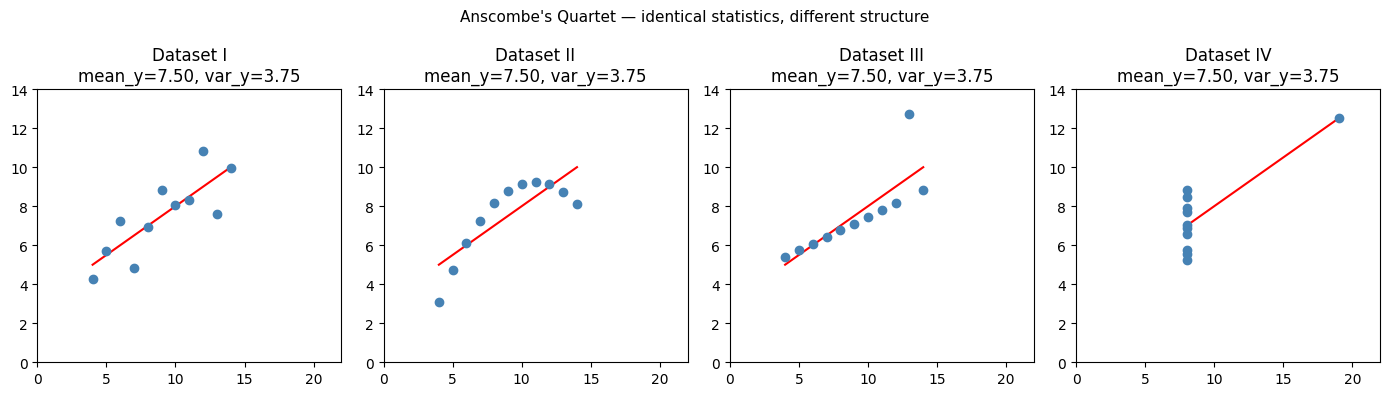

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Anscombe's Quartet — hardcoded
anscombe = {
    'I':   {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    'II':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [9.14,8.14,8.74,8.77,9.26,8.1,6.13,3.1,9.13,7.26,4.74]},
    'III': {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    'IV':  {'x': [8,8,8,8,8,8,8,19,8,8,8],
             'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.5,5.56,7.91,6.89]},
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, d) in zip(axes, anscombe.items()):
    x, y = np.array(d['x']), np.array(d['y'])
    m = np.polyfit(x, y, 1)
    xline = np.linspace(min(x), max(x), 100)
    ax.scatter(x, y, color='steelblue', zorder=5)
    ax.plot(xline, np.polyval(m, xline), 'r-', lw=1.5)
    ax.set_title(f'Dataset {name}\nmean_y={y.mean():.2f}, var_y={y.var():.2f}')
    ax.set_xlim(0, 22); ax.set_ylim(0, 14)

plt.suptitle("Anscombe's Quartet — identical statistics, different structure", fontsize=11)
plt.tight_layout()
plt.show()

## 2. Chart Selection by Variable Type

| Goal | Variable types | Chart |
|---|---|---|
| Distribution of one variable | Continuous | Histogram, KDE, box plot |
| Distribution of one variable | Categorical | Bar chart |
| Two continuous variables | Continuous × Continuous | Scatter plot |
| One continuous, one categorical | Cont × Cat | Grouped box plot, violin |
| Trend over time | Continuous × Time | Line chart |
| Part-to-whole | Categorical | Stacked bar, NOT pie |
| Many variables simultaneously | Mixed | Pair plot, heatmap |

C:\Users\user\AppData\Local\Temp\ipykernel_2424\2600657.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(list(group_data.values()), labels=list(group_data.keys()),


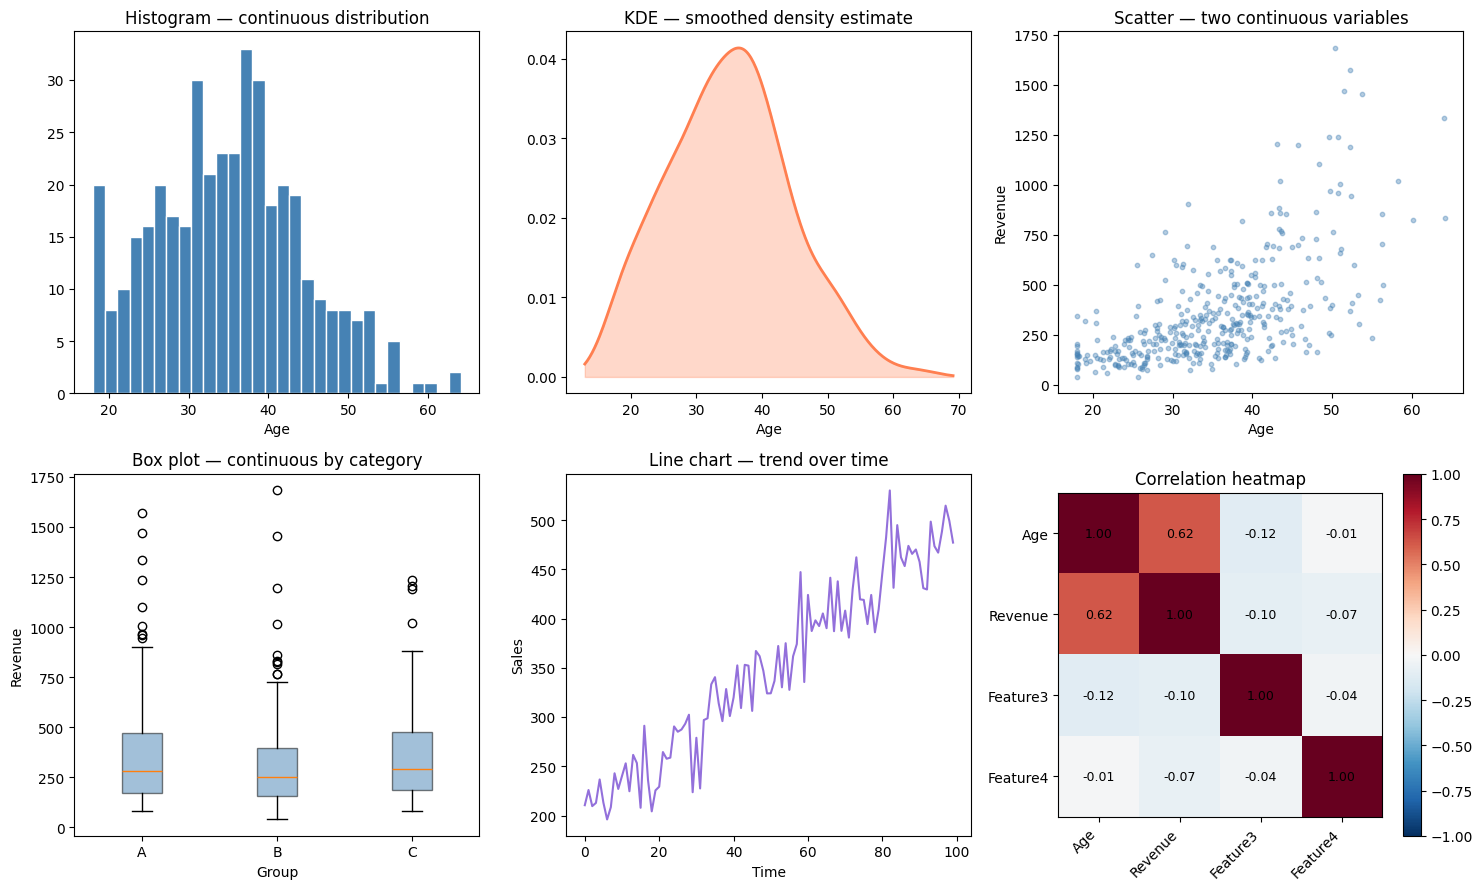

In [2]:
rng = np.random.default_rng(42)
n = 400

age     = rng.normal(35, 10, n).clip(18, 65)
revenue = np.exp(0.05 * age + rng.normal(0, 0.5, n)) * 50
group   = rng.choice(['A', 'B', 'C'], n)
time    = np.arange(100)
sales   = 200 + 3 * time + rng.normal(0, 30, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Histogram
ax = axes[0, 0]
ax.hist(age, bins=30, color='steelblue', edgecolor='white')
ax.set_title('Histogram — continuous distribution')
ax.set_xlabel('Age')

# 2. KDE (manually computed)
ax = axes[0, 1]
x_grid = np.linspace(age.min() - 5, age.max() + 5, 300)
h = 1.06 * age.std() * len(age)**(-0.2)  # Silverman's rule
kde = np.mean(np.exp(-0.5 * ((x_grid[:, None] - age[None, :]) / h)**2), axis=1) / (h * np.sqrt(2*np.pi))
ax.plot(x_grid, kde, color='coral', lw=2)
ax.fill_between(x_grid, kde, alpha=0.3, color='coral')
ax.set_title('KDE — smoothed density estimate')
ax.set_xlabel('Age')

# 3. Scatter
ax = axes[0, 2]
ax.scatter(age, revenue, s=10, alpha=0.4, color='steelblue')
ax.set_title('Scatter — two continuous variables')
ax.set_xlabel('Age'); ax.set_ylabel('Revenue')

# 4. Grouped box plot
ax = axes[1, 0]
group_data = {g: revenue[group == g] for g in ['A', 'B', 'C']}
ax.boxplot(list(group_data.values()), labels=list(group_data.keys()),
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_title('Box plot — continuous by category')
ax.set_xlabel('Group'); ax.set_ylabel('Revenue')

# 5. Line chart
ax = axes[1, 1]
ax.plot(time, sales, color='mediumpurple', lw=1.5)
ax.set_title('Line chart — trend over time')
ax.set_xlabel('Time'); ax.set_ylabel('Sales')

# 6. Correlation heatmap
ax = axes[1, 2]
features = np.column_stack([age, revenue, rng.normal(0,1,n), rng.normal(0,1,n)])
labels   = ['Age', 'Revenue', 'Feature3', 'Feature4']
C = np.corrcoef(features.T)
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{C[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title('Correlation heatmap')

plt.tight_layout()
plt.show()

## 3. Charts That Lie

Not all charts are honest. Common misleading practices:

1. **Truncated y-axis**: starts at non-zero, exaggerates small differences
2. **Area encoding for 1D data**: pie charts where angle ≠ area (3D pie especially)
3. **Dual y-axes**: implies correlation between unrelated series by scaling
4. **Log scale without labeling**: obscures the nature of the scale

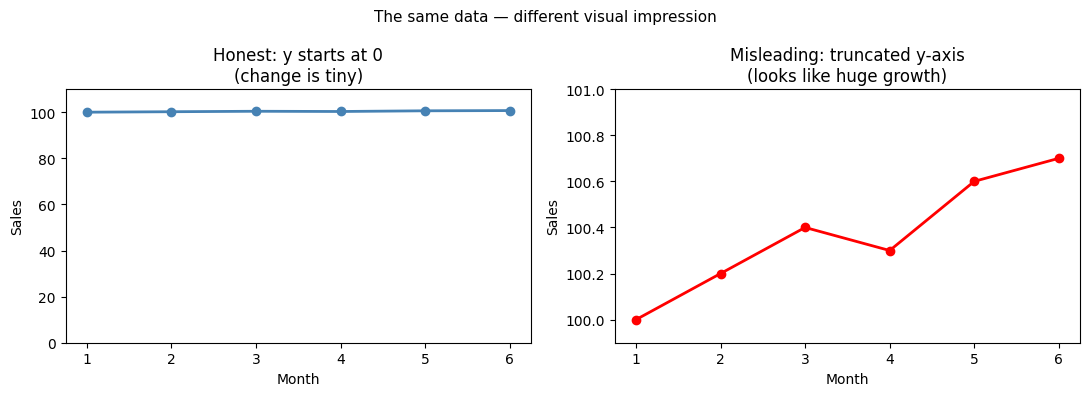

Actual change:  0.7000000000000028  (0.7% over 5 months)


In [3]:
months   = np.arange(1, 7)
sales_a  = np.array([100.0, 100.2, 100.4, 100.3, 100.6, 100.7])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(months, sales_a, 'o-', color='steelblue', lw=2)
ax1.set_ylim(0, 110)
ax1.set_title('Honest: y starts at 0\n(change is tiny)')
ax1.set_xlabel('Month'); ax1.set_ylabel('Sales')

ax2.plot(months, sales_a, 'o-', color='red', lw=2)
ax2.set_ylim(99.9, 101.0)  # truncated
ax2.set_title('Misleading: truncated y-axis\n(looks like huge growth)')
ax2.set_xlabel('Month'); ax2.set_ylabel('Sales')

plt.suptitle('The same data — different visual impression', fontsize=11)
plt.tight_layout()
plt.show()

print("Actual change: ", sales_a[-1] - sales_a[0], " (0.7% over 5 months)")

## 4. Pair Plots — Seeing Multiple Variables

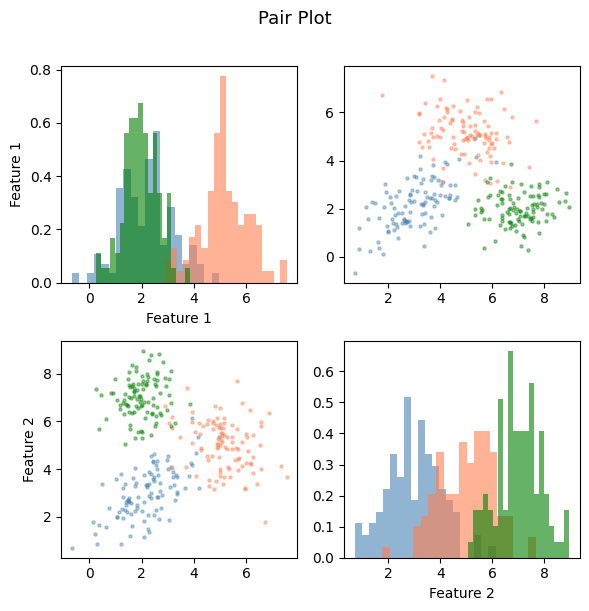

In [4]:
def pair_plot(data_matrix: np.ndarray, labels: list[str], colors: np.ndarray = None):
    """Simple pair plot implemented from scratch."""
    p = data_matrix.shape[1]
    fig, axes = plt.subplots(p, p, figsize=(3*p, 3*p))

    if colors is None:
        colors = np.zeros(len(data_matrix), dtype=int)
    palette = ['steelblue', 'coral', 'green']

    for i in range(p):
        for j in range(p):
            ax = axes[i, j]
            if i == j:
                for c in np.unique(colors):
                    ax.hist(data_matrix[colors == c, i], bins=20,
                            color=palette[c], alpha=0.6, density=True)
                ax.set_xlabel(labels[i])
            else:
                for c in np.unique(colors):
                    mask = colors == c
                    ax.scatter(data_matrix[mask, j], data_matrix[mask, i],
                               s=5, alpha=0.4, color=palette[c])
            if j == 0: ax.set_ylabel(labels[i])

    plt.suptitle('Pair Plot', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Generate 3-class data
n_per_class = 100
X = np.vstack([
    rng.multivariate_normal([2, 3], [[1, 0.5],[0.5, 1]], n_per_class),
    rng.multivariate_normal([5, 5], [[1, -0.3],[-0.3, 1]], n_per_class),
    rng.multivariate_normal([2, 7], [[0.5, 0],[0, 0.5]], n_per_class),
])
y_cls = np.repeat([0, 1, 2], n_per_class)

pair_plot(X, ['Feature 1', 'Feature 2'], colors=y_cls)

## 5. What Comes Next

Visualization is inherently exploratory. To make decisions from data, you need formal procedures. **ch275 — Sampling** addresses the question of how datasets are collected and what guarantees that gives you about inference. **ch277 — Hypothesis Testing** provides the framework for converting visual patterns into statistically defensible claims.

The correlation heatmap shown here will be formalized in **ch280 — Correlation** and extended to the full covariance matrix used in **ch292 — Dimensionality Reduction**.